Epoch 0, Loss: 1.2162e-01, Res: 1.63e-03, Fourier: 1.20e-01
Epoch 500, Loss: 1.6986e-04, Res: 1.16e-04, Fourier: 5.36e-05
Epoch 1000, Loss: 2.3551e-04, Res: 4.81e-05, Fourier: 1.87e-04
Epoch 1500, Loss: 4.3413e-05, Res: 2.74e-05, Fourier: 1.60e-05


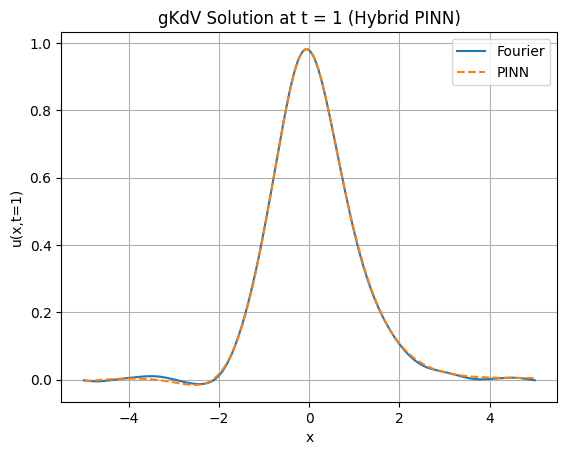

Relative L2 error at t = 1: 1.1046e-02


In [ ]:
# ============================================
# HÍBRIDO 1: PINN + Supervisión por Solución Espectral
# ============================================
import torch
import torch.nn as nn
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# Configuración del dominio
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
x = np.linspace(-L, L, N, endpoint=False)
t_vals = np.linspace(0, t_max, nt + 1)

# Parámetros PDE
alpha, nu, gamma = 1.0, 3.0, 0.1

# Condición inicial sin ruido
u0 = 1 / np.cosh(x) ** 2

# Solver espectral
k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
ik3 = (1j * k) ** 3
u = u0.copy()
u_spectral = [u0.copy()]
for _ in range(nt):
    u_hat = fft(u)
    u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
    u = u_disp - dt * alpha * u_disp ** nu * np.gradient(u_disp, x[1] - x[0])
    u_spectral.append(u.copy())
u_spectral = np.array(u_spectral)

# Interpolador
interp = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)
def u_fourier_interp(x_input, t_input):
    pts = np.stack([t_input.flatten(), x_input.flatten()], axis=-1)
    return interp(pts)

# Red PINN
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i + 1]) if i == len(layers) - 2 else
              nn.Sequential(nn.Linear(layers[i], layers[i + 1]), nn.Tanh())
              for i in range(len(layers) - 1)]
        )
    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# Entrenamiento
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    optimizer.zero_grad()
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# Visualización
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('gKdV Solution at t = 1 (Hybrid PINN)')
plt.xlabel('x')
plt.ylabel('u(x,t=1)')
plt.grid(True)
plt.show()

# Error relativo L2
rel_L2 = np.sqrt(np.sum((u_pinn - u_true) ** 2) / np.sum(u_true ** 2))
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")



Epoch 0, Total Loss: 1.3960e-01, IC Loss: 1.39e-01, Residual Loss: 3.84e-04
Epoch 500, Total Loss: 2.1503e-04, IC Loss: 6.88e-05, Residual Loss: 1.46e-04
Epoch 1000, Total Loss: 1.2076e-04, IC Loss: 4.29e-05, Residual Loss: 7.79e-05
Epoch 1500, Total Loss: 7.9412e-05, IC Loss: 3.57e-05, Residual Loss: 4.37e-05


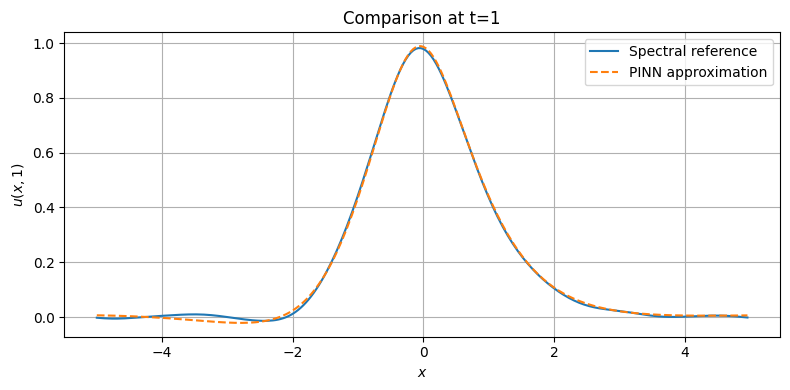

Mean Squared Error (MSE) at t = 1: 7.4619e-05
Relative L2 error at t = 1: 2.3657e-02


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# =======================
# Parámetros del problema
# =======================
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)

alpha, nu, gamma = 1.0, 3.0, 0.1

x_vals = np.linspace(-L, L, N, endpoint=False)
dx = x_vals[1] - x_vals[0]
t_vals = np.linspace(0, t_max, nt + 1)

# ==============================
# Condición inicial y solución espectral
# ==============================
def u0(x):
    return 1 / np.cosh(x)**2

# Método espectral como solución de referencia
def solver_espectral(u0, x, dt, nt):
    k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
    ik3 = (1j * k) ** 3
    u = u0.copy()
    u_spectral = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, x[1] - x[0])
        u_spectral.append(u.copy())
    return np.array(u_spectral)

u_spectral = solver_espectral(u0(x_vals), x_vals, dt, nt)
u_true_t1 = u_spectral[-1]  # tiempo final t = 1

# ==============================
# Red neuronal PINN
# ==============================
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i + 1]) if i == len(layers) - 2 else
              nn.Sequential(nn.Linear(layers[i], layers[i + 1]), nn.Tanh())
              for i in range(len(layers) - 1)]
        )
    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

# ==============================
# Residuo gKdV
# ==============================
def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# ==============================
# Entrenamiento PINN puro
# ==============================
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    optimizer.zero_grad()

    # Puntos de colisión (residuo)
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    # Condición inicial
    x_ic = torch.tensor(np.random.uniform(-L, L, (256, 1)), dtype=torch.float32)
    t_ic = torch.zeros_like(x_ic)
    u_ic = torch.tensor(u0(x_ic.numpy()), dtype=torch.float32)

    # Cálculo de pérdidas
    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    loss = loss_res + loss_ic
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Total Loss: {loss.item():.4e}, IC Loss: {loss_ic.item():.2e}, Residual Loss: {loss_res.item():.2e}")

# ==============================
# Evaluación al tiempo t = 1
# ==============================
x_eval = torch.tensor(x_vals.reshape(-1, 1), dtype=torch.float32)
t_eval = torch.full_like(x_eval, t_max)
u_pred_t1 = model(x_eval, t_eval).detach().numpy().flatten()

# ==============================
# Visualización y error
# ==============================
plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_true_t1, label='Spectral reference')
plt.plot(x_vals, u_pred_t1, '--', label='PINN approximation')
plt.xlabel('$x$')
plt.ylabel('$u(x,1)$')
plt.title('Comparison at t=1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rel_L2 = np.sqrt(np.sum((u_pred_t1 - u_true_t1)**2) / np.sum(u_true_t1**2))
mse = np.mean((u_pred_t1 - u_true_t1)**2)
print(f"Mean Squared Error (MSE) at t = 1: {mse:.4e}")
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# =======================
# Parámetros del problema
# =======================
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)

alpha, nu, gamma = 1.0, 2.0, 0.1

x_vals = np.linspace(-L, L, N, endpoint=False)
dx = x_vals[1] - x_vals[0]
t_vals = np.linspace(0, t_max, nt + 1)

# ==============================
# Condición inicial y solución espectral
# ==============================
def u0(x):
    return 1 / np.cosh(x)**2

# Método espectral como solución de referencia
def solver_espectral(u0, x, dt, nt):
    k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
    ik3 = (1j * k) ** 3
    u = u0.copy()
    u_spectral = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, x[1] - x[0])
        u_spectral.append(u.copy())
    return np.array(u_spectral)

u_spectral = solver_espectral(u0(x_vals), x_vals, dt, nt)
u_true_t1 = u_spectral[-1]  # tiempo final t = 1



# ========= Obtener solución espectral con nu = 2 =========
u_spectral = solver_espectral(u0(x_vals), x_vals, dt, nt)

# ========= Extraer t = 0 y t = 0.8 =========
u_t0 = u_spectral[0]
u_t08 = u_spectral[int(0.8 / dt)]


# ==============================
# Visualización y error
# ==============================
plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_t0, label='t = 0')
plt.plot(x_vals, u_t08, label='t = 0.8')
plt.xlabel('$x$')
plt.ylabel('$u(x,t)$')
plt.title('Spectral solution for $\\nu = 2$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rel_L2 = np.sqrt(np.sum((u_pred_t1 - u_true_t1)**2) / np.sum(u_true_t1**2))
mse = np.mean((u_pred_t1 - u_true_t1)**2)
print(f"Mean Squared Error (MSE) at t = 1: {mse:.4e}")
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


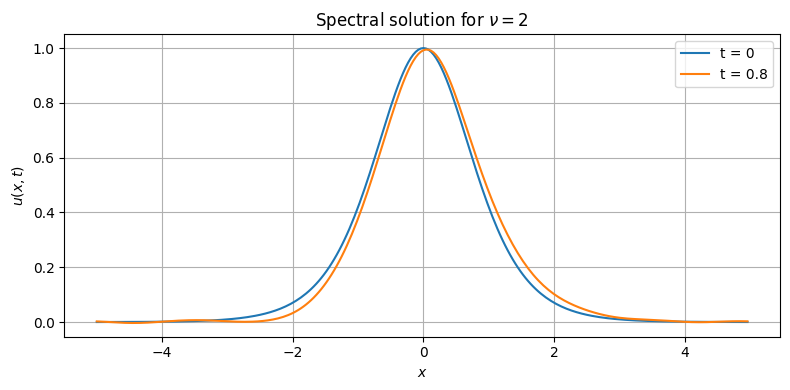

In [5]:
import torch
import torch.nn as nn
import numpy as np
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# =======================
# Parámetros del problema
# =======================
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)

alpha, nu, gamma = 1.0, 2.0, 0.1

x_vals = np.linspace(-L, L, N, endpoint=False)

# ==============================
# Condición inicial
# ==============================
def u0(x):
    return 1 / np.cosh(x)**2

# ==============================
# Método espectral como referencia
# ==============================
def solver_espectral(u0, x, dt, nt):
    k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
    ik3 = (1j * k) ** 3
    u = u0.copy()
    u_spectral = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, x[1] - x[0])
        u_spectral.append(u.copy())
    return np.array(u_spectral)

# ==============================
# Solución espectral y extracción de tiempos
# ==============================
u_spectral = solver_espectral(u0(x_vals), x_vals, dt, nt)
u_t0 = u_spectral[0]
u_t08 = u_spectral[int(0.8 / dt)]

# ==============================
# Visualización
# ==============================
plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_t0, label='t = 0')
plt.plot(x_vals, u_t08, label='t = 0.8')
plt.xlabel('$x$')
plt.ylabel('$u(x,t)$')
plt.title('Spectral solution for $\\nu = 2$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# =======================
# Parámetros del problema
# =======================
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)

alpha, nu, gamma = 1.0, 3.0, 0.1

x_vals = np.linspace(-L, L, N, endpoint=False)
dx = x_vals[1] - x_vals[0]
t_vals = np.linspace(0, t_max, nt + 1)

# ==============================
# Condición inicial y solución espectral
# ==============================
def u0(x):
    return 1 / np.cosh(x)**2

def solver_espectral(u0, x, dt, nt):
    k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
    ik3 = (1j * k) ** 3
    u = u0.copy()
    u_spectral = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, x[1] - x[0])
        u_spectral.append(u.copy())
    return np.array(u_spectral)

u_spectral = solver_espectral(u0(x_vals), x_vals, dt, nt)
u_true_t1 = u_spectral[-1]

# ==============================
# Red neuronal PINN
# ==============================
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i + 1]) if i == len(layers) - 2 else
              nn.Sequential(nn.Linear(layers[i], layers[i + 1]), nn.Tanh())
              for i in range(len(layers) - 1)]
        )
    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

# ==============================
# Residuo gKdV
# ==============================
def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# ==============================
# Entrenamiento PINN puro
# ==============================
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3000):
    optimizer.zero_grad()

    x_coll = torch.tensor(np.random.uniform(-L, L, (10000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (10000, 1)), dtype=torch.float32)

    x_ic = torch.tensor(np.random.uniform(-L, L, (200, 1)), dtype=torch.float32)
    t_ic = torch.zeros_like(x_ic)
    u_ic = torch.tensor(u0(x_ic.numpy()), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    loss = loss_res + loss_ic
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Total Loss: {loss.item():.4e}, IC Loss: {loss_ic.item():.2e}, Residual Loss: {loss_res.item():.2e}")

# ==============================
# Evaluación y visualización
# ==============================
x_eval = torch.tensor(x_vals.reshape(-1, 1), dtype=torch.float32)
t_eval = torch.full_like(x_eval, t_max)
u_pred_t1 = model(x_eval, t_eval).detach().numpy().flatten()

plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_true_t1, label='Spectral Reference')
plt.plot(x_vals, u_pred_t1, '--', label='PINN Approximation')
plt.xlabel('$x$')
plt.ylabel('$u(x,1)$')
plt.title('Comparison at $t=1$ for gKdV with $\\nu=3$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mse = np.mean((u_pred_t1 - u_true_t1)**2)
rel_L2 = np.sqrt(np.sum((u_pred_t1 - u_true_t1)**2) / np.sum(u_true_t1**2))
print(f"Mean Squared Error (MSE) at t = 1: {mse:.4e}")
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


Epoch 0, Total Loss: 1.5454e-01, IC Loss: 1.54e-01, Residual Loss: 3.22e-04
Epoch 500, Total Loss: 1.3912e-04, IC Loss: 2.53e-05, Residual Loss: 1.14e-04


KeyboardInterrupt: 

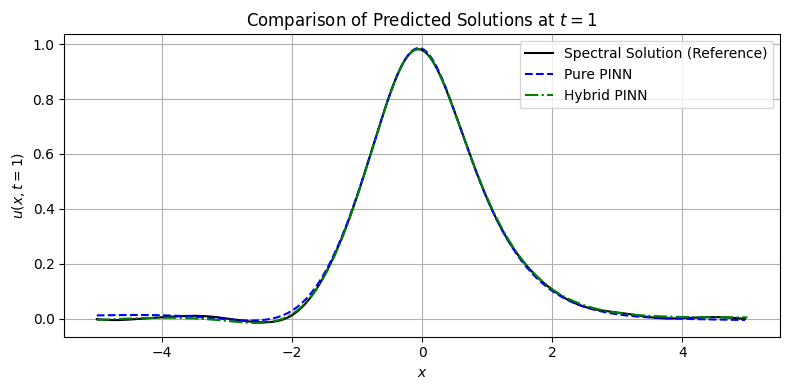

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que ya tienes los siguientes arrays disponibles:
# x_vals: puntos espaciales
# u_true_t1: solución espectral en t=1
# u_pinn_puro: predicción del PINN puro en t=1
# u_pinn_hibrido: predicción del PINN híbrido en t=1

plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_true_t1, 'k-', label='Spectral Solution (Reference)')
plt.plot(x_vals, u_pred_t1, 'b--', label='Pure PINN')
plt.plot(x_plot, u_pinn, 'g-.', label='Hybrid PINN')
plt.xlabel('$x$')
plt.ylabel('$u(x,t=1)$')
plt.title('Comparison of Predicted Solutions at $t = 1$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("comparison_plot.png", dpi=300)
plt.show()


Epoch 0, Loss: 2.1404e-01, Res: 4.97e-03, Fourier: 2.09e-01
Epoch 500, Loss: 1.3555e-04, Res: 1.05e-04, Fourier: 3.10e-05
Epoch 1000, Loss: 8.3852e-05, Res: 5.61e-05, Fourier: 2.77e-05
Epoch 1500, Loss: 8.6401e-05, Res: 3.34e-05, Fourier: 5.30e-05


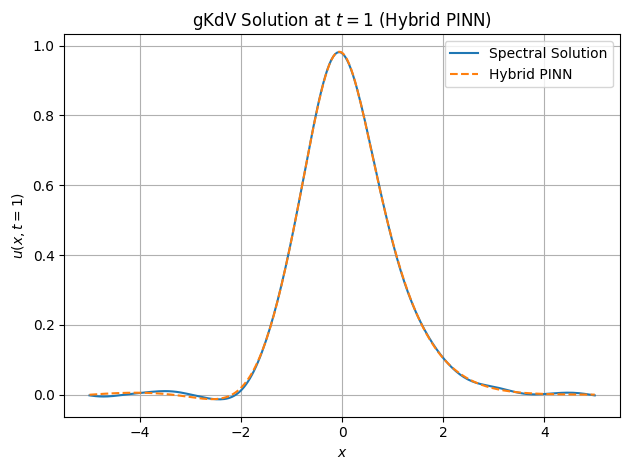

Relative L2 error at t = 1: 1.0680e-02


In [ ]:
# ============================================
# HYBRID 1: PINN + Supervision via Spectral Solution
# ============================================
import torch
import torch.nn as nn
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# Domain configuration
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
x = np.linspace(-L, L, N, endpoint=False)
t_vals = np.linspace(0, t_max, nt + 1)

# PDE parameters
alpha, nu, gamma = 1.0, 3.0, 0.1

# Initial condition (noiseless)
u0 = 1 / np.cosh(x) ** 2

# Spectral solver (used only as reference)
k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
ik3 = (1j * k) ** 3
u = u0.copy()
u_spectral = [u0.copy()]
for _ in range(nt):
    u_hat = fft(u)
    u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
    u = u_disp - dt * alpha * u_disp ** nu * np.gradient(u_disp, x[1] - x[0])
    u_spectral.append(u.copy())
u_spectral = np.array(u_spectral)

# Interpolator for spectral solution
interp = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)
def u_fourier_interp(x_input, t_input):
    pts = np.stack([t_input.flatten(), x_input.flatten()], axis=-1)
    return interp(pts)

# PINN model
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i + 1]) if i == len(layers) - 2 else
              nn.Sequential(nn.Linear(layers[i], layers[i + 1]), nn.Tanh())
              for i in range(len(layers) - 1)]
        )
    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

# PDE residual for gKdV equation
def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# Training
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    optimizer.zero_grad()

    # Collocation points
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    # Residual loss
    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    # Supervised loss from spectral solution
    u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    # Total loss
    loss = loss_res + loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# Evaluation at final time t = 1
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

# Visualization
plt.plot(x_plot.numpy(), u_true, label='Spectral Solution')
plt.plot(x_plot.numpy(), u_pinn, '--', label='Hybrid PINN')
plt.legend()
plt.title('gKdV Solution at $t = 1$ (Hybrid PINN)')
plt.xlabel('$x$')
plt.ylabel('$u(x,t=1)$')
plt.grid(True)
plt.tight_layout()
plt.show()

# Relative L2 error
rel_L2 = np.sqrt(np.sum((u_pinn - u_true) ** 2) / np.sum(u_true ** 2))
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")


Epoch 0, Total Loss: 1.8371e-01, IC Loss: 1.83e-01, Residual Loss: 3.26e-04
Epoch 500, Total Loss: 1.6744e-04, IC Loss: 3.66e-05, Residual Loss: 1.31e-04
Epoch 1000, Total Loss: 8.8982e-05, IC Loss: 2.22e-05, Residual Loss: 6.68e-05
Epoch 1500, Total Loss: 7.2470e-05, IC Loss: 2.91e-05, Residual Loss: 4.33e-05


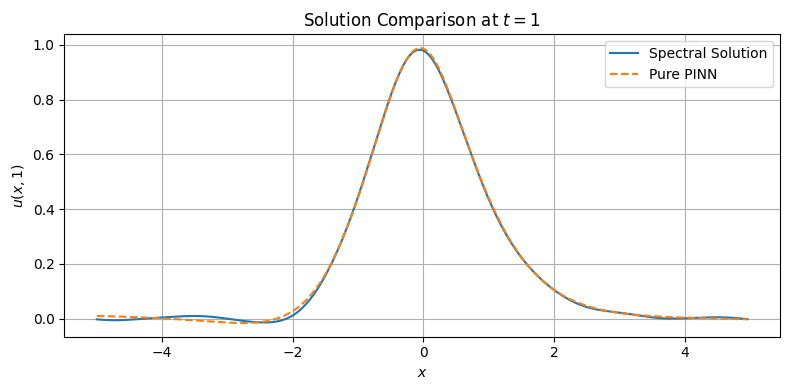

Relative L2 error at t = 1: 2.0570e-02


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# =======================
# Problem Parameters
# =======================
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)

alpha, nu, gamma = 1.0, 3.0, 0.1

x_vals = np.linspace(-L, L, N, endpoint=False)
dx = x_vals[1] - x_vals[0]
t_vals = np.linspace(0, t_max, nt + 1)

# ==============================
# Initial Condition and Reference Solution
# ==============================
def u0(x):
    return 1 / np.cosh(x)**2

# Spectral solver for reference solution
def spectral_solver(u0, x, dt, nt):
    k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
    ik3 = (1j * k) ** 3
    u = u0.copy()
    u_spectral = [u0.copy()]
    for _ in range(nt):
        u_hat = fft(u)
        u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
        u = u_disp - dt * alpha * u_disp**nu * np.gradient(u_disp, x[1] - x[0])
        u_spectral.append(u.copy())
    return np.array(u_spectral)

u_spectral = spectral_solver(u0(x_vals), x_vals, dt, nt)
u_true_t1 = u_spectral[-1]  # final time t = 1

# ==============================
# PINN Neural Network
# ==============================
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i + 1]) if i == len(layers) - 2 else
              nn.Sequential(nn.Linear(layers[i], layers[i + 1]), nn.Tanh())
              for i in range(len(layers) - 1)]
        )
    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

# ==============================
# gKdV Residual
# ==============================
def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# ==============================
# Pure PINN Training
# ==============================
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    optimizer.zero_grad()

    # Collocation points (PDE residual)
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    # Initial condition points
    x_ic = torch.tensor(np.random.uniform(-L, L, (256, 1)), dtype=torch.float32)
    t_ic = torch.zeros_like(x_ic)
    u_ic = torch.tensor(u0(x_ic.numpy()), dtype=torch.float32)

    # Compute losses
    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    loss = loss_res + loss_ic
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Total Loss: {loss.item():.4e}, IC Loss: {loss_ic.item():.2e}, Residual Loss: {loss_res.item():.2e}")

# ==============================
# Evaluation at Final Time t = 1
# ==============================
x_eval = torch.tensor(x_vals.reshape(-1, 1), dtype=torch.float32)
t_eval = torch.full_like(x_eval, t_max)
u_pred_t1 = model(x_eval, t_eval).detach().numpy().flatten()

# ==============================
# Visualization and L2 Error
# ==============================
plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_true_t1, label='Spectral Solution')
plt.plot(x_vals, u_pred_t1, '--', label='Pure PINN')
plt.xlabel('$x$')
plt.ylabel('$u(x,1)$')
plt.title('Solution Comparison at $t=1$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Relative L2 Error
rel_L2 = np.sqrt(np.sum((u_pred_t1 - u_true_t1)**2) / np.sum(u_true_t1**2))
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")
